# Transformer 기반 한국어 챗봇  
## 재설계 v4: 응답 품질 개선 + TF-IDF 검색형 fallback

이 노트북은 v3의 학습 구조를 유지하면서, 실제 응답 품질을 끌어올리기 위해 다음을 추가했다.

1. **Transformer 생성 응답 단독 사용 금지**  
   작은 한국어 Q/A 데이터셋으로 scratch Transformer를 학습하면 검증 문장에서 엉뚱한 답변이 쉽게 나온다.

2. **문자 n-gram TF-IDF 검색형 응답 추가**  
   한국어는 공백 기준 단어 토큰화만으로 유사도를 잡기 어렵다. 그래서 `char_wb` 기반 2~5gram TF-IDF 검색을 사용한다.

3. **생성 응답 품질 게이트 추가**  
   `<unk>`, 과도한 반복, 지나치게 짧은 답변, 맥락 약한 일반 답변을 감지해 검색형 답변으로 fallback한다.

4. **최종 응답 함수 통합**  
   `final_chatbot_response()` 하나로 생성형/검색형/품질 차단 결과를 확인할 수 있다.

> 결론: 이 v4는 “Transformer 생성형 챗봇 과제 구조”는 유지하되, 실제 사용자 응답은 **검색형 우선 + 생성형 보조** 방식으로 안정화한 버전이다.

## 1단계. 라이브러리 준비

In [12]:
import math
import re
import random
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# v4 추가: 한국어 짧은 문장 검색형 fallback용
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2단계. 데이터 로드

`songys/Chatbot_data`의 `ChatbotData.csv` (Q, A 컬럼). 약 11,823건의 한국어 질문-답변 쌍.

In [13]:
DATA_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"

try:
    df = pd.read_csv(DATA_URL)
    print("온라인 데이터셋 로드 성공")
except Exception as e:
    print("온라인 로드 실패, 오프라인 fallback 사용:", e)
    df = pd.DataFrame({
        "Q": ["안녕하세요", "오늘 날씨 어때", "점심 뭐 먹지", "공부 하기 싫다",
              "주말에 뭐 할까", "기분이 좋아", "친구랑 싸웠어", "잠이 안 와"],
        "A": ["반가워요", "오늘은 맑은 날이에요", "맛있는 거 드세요", "조금 쉬어가도 좋아요",
              "친구를 만나보는 건 어때요", "좋은 하루네요", "마음을 풀어보세요", "따뜻한 차 한 잔 어때요"]
    })

df = df[["Q", "A"]].dropna().reset_index(drop=True)
print("원본 데이터 개수:", len(df))
df.head()

온라인 데이터셋 로드 성공
원본 데이터 개수: 11823


,Q,A
0,12시 땡!,하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.


## 3단계. 전처리 (정규식 백레퍼런스 수정)

이전 버전의 핵심 버그는 `re.sub(r"([?.!,])", r" \u0001 ", s)`. `\u0001`은 백레퍼런스가 아니라 SOH 제어문자라서 문장부호가 그 문자로 치환되었고, 바로 다음 줄에서 공백으로 날아갔다. 이 함수가 통과시킨 문장에는 부호가 하나도 안 남았다는 뜻이다.

올바른 형태는 캡처 그룹 백레퍼런스 `\1`이다.

```text
잘못된 결과: "지루하다, 놀러가고 싶어." → "지루하다 놀러가고 싶어"
올바른 결과: "지루하다, 놀러가고 싶어." → "지루하다 , 놀러가고 싶어 ."
```

문장부호가 살아 있어야 다음 단계의 augmentation이 실제로 동작한다.

In [14]:
def preprocess_sentence(sentence):
    """
    한국어 문장을 모델 학습용으로 정리한다.
    1) 앞뒤 공백 제거
    2) 문장부호 주변에 공백 (← 백레퍼런스 \1 정정)
    3) 한글/영문/숫자/기본 문장부호 외 문자 제거
    4) 중복 공백 정리
    """
    sentence = str(sentence).strip()

    # FIX: \u0001(SOH 제어문자) -> \1(백레퍼런스)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,\s]", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence


df["Q_clean"] = df["Q"].apply(preprocess_sentence)
df["A_clean"] = df["A"].apply(preprocess_sentence)

# 빈 문장 제거 (전처리 후 비어 버린 행이 있으면 학습에 방해됨)
df = df[(df["Q_clean"].str.len() > 0) & (df["A_clean"].str.len() > 0)].reset_index(drop=True)

print("전처리 후 데이터 개수:", len(df))
print("\n부호가 분리되어 남는지 확인:")
df[["Q", "Q_clean", "A", "A_clean"]].head()

전처리 후 데이터 개수: 11823

부호가 분리되어 남는지 확인:


,Q,Q_clean,A,A_clean
0,12시 땡!,12시 땡 !,하루가 또 가네요.,하루가 또 가네요 .
1,1지망 학교 떨어졌어,1지망 학교 떨어졌어,위로해 드립니다.,위로해 드립니다 .
2,3박4일 놀러가고 싶다,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,여행은 언제나 좋죠 .
3,3박4일 정도 놀러가고 싶다,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,여행은 언제나 좋죠 .
4,PPL 심하네,PPL 심하네,눈살이 찌푸려지죠.,눈살이 찌푸려지죠 .


## 4단계. train/val을 **먼저** 분리 (누수 차단)

이전 버전의 실수: `concat([df] * repeat)`로 같은 행을 2~3배 복제해 30000개를 만든 뒤, 그 30000개를 `random_split`으로 9:1 분할했다. 결과적으로 동일한 (Q, A) 쌍의 사본이 train과 val에 양쪽 모두 들어갔다.

**올바른 순서: 원본을 먼저 분할 → 그 다음 train에만 augmentation.**

이러면 val은 augmentation을 한 번도 보지 않은 원본만 남아, 진짜 일반화 성능을 측정할 수 있다.

In [15]:
# 셔플 후 9:1 분할 (원본 기준)
shuffled = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

val_n = len(shuffled) // 10
val_df = shuffled.iloc[:val_n].reset_index(drop=True)
train_df_orig = shuffled.iloc[val_n:].reset_index(drop=True)

print(f"원본 분할 결과 — train: {len(train_df_orig)}  val: {len(val_df)}")
print("(이 시점에서 train과 val 사이에 동일 행이 존재하지 않음)")

원본 분할 결과 — train: 10641  val: 1182
(이 시점에서 train과 val 사이에 동일 행이 존재하지 않음)


## 5단계. Augmentation (train에만 적용)

질문 문장의 의미를 크게 바꾸지 않으면서 자연스럽게 늘릴 수 있는 6가지 변형을 쓴다. 답변 `A`는 그대로 둔다 — 질문의 표면 표현만 바뀌는 것이므로 같은 답변이 유효하다.

| 종류 | 설명 | 예시 ("오늘 일찍 일어났더니 피곤하다 .") |
|---|---|---|
| 원문 유지 | 베이스 | "오늘 일찍 일어났더니 피곤하다 ." |
| 마침표→느낌표 | 감정 톤 변화 | "오늘 일찍 일어났더니 피곤하다 !" |
| 문장부호 제거 | 부호 없는 변형 | "오늘 일찍 일어났더니 피곤하다" |
| 말줄임표 | 대화체 느낌 | "오늘 일찍 일어났더니 피곤하다 ..." |
| EDA Random Deletion | 단어 1개 제거 (≥4단어일 때) | "일찍 일어났더니 피곤하다 ." |
| EDA Random Swap | 인접 단어 1쌍 교환 (≥4단어일 때) | "일찍 오늘 일어났더니 피곤하다 ." |

평균 약 2.7배 증강이 자연스럽게 만들어진다. 11823 × 0.9(train) × 2.7 ≈ 약 28,700개로 거의 30k에 자연 도달한다. 부족분은 추가 EDA 패스로 채우고, 초과분은 샘플링으로 깎는다 — **단순 복제는 사용하지 않는다.**

In [16]:
PUNCT_TOKENS = {".", "?", "!", ","}

def augment_question(q, rng):
    """
    질문 한 줄에 대해 의미 보존형 변형 후보를 생성한다.
    답변(A)의 정답성이 깨지지 않을 정도의 약한 변형만 사용한다.
    """
    tokens = q.split()
    out = [q]  # 원문은 항상 포함

    # (a) 마침표 -> 느낌표
    if "." in tokens:
        out.append(" ".join("!" if t == "." else t for t in tokens))

    # (b) 문장부호 전체 제거
    stripped = [t for t in tokens if t not in PUNCT_TOKENS]
    if stripped and stripped != tokens:
        out.append(" ".join(stripped))

    # (c) 말줄임표 ending
    if tokens and tokens[-1] == ".":
        out.append(" ".join(tokens[:-1] + ["..."]))

    # (d) EDA - Random Deletion: 단어 토큰 중 1개 제거
    word_idx = [i for i, t in enumerate(tokens) if t not in PUNCT_TOKENS]
    if len(word_idx) >= 4:
        drop = rng.choice(word_idx)
        out.append(" ".join(t for i, t in enumerate(tokens) if i != drop))

    # (e) EDA - Random Swap: 인접한 단어 2개 교환
    if len(word_idx) >= 4:
        adj = [(word_idx[i], word_idx[i+1])
               for i in range(len(word_idx) - 1)
               if word_idx[i+1] == word_idx[i] + 1]
        if adj:
            a, b = rng.choice(adj)
            new = tokens.copy()
            new[a], new[b] = new[b], new[a]
            out.append(" ".join(new))

    return list(dict.fromkeys(out))  # 순서 유지 + dedup


# train에만 적용 (val은 건드리지 않는다)
rng = random.Random(SEED)
aug_rows = []
for _, row in train_df_orig.iterrows():
    for aq in augment_question(row["Q_clean"], rng):
        aug_rows.append({"Q_clean": aq, "A_clean": row["A_clean"]})

train_aug_df = pd.DataFrame(aug_rows).drop_duplicates().reset_index(drop=True)
print(f"1차 증강 후 train: {len(train_aug_df)}  (배수: {len(train_aug_df)/len(train_df_orig):.2f}x)")

# 30k 목표에 부족하면 다른 시드로 한 번 더 EDA 패스 (복제가 아니라 다른 변형)
TARGET = 30000
pass_rng = random.Random(SEED + 1)
passes = 0
while len(train_aug_df) < TARGET and passes < 3:
    extra = []
    for _, row in train_df_orig.iterrows():
        tokens = row["Q_clean"].split()
        word_idx = [i for i, t in enumerate(tokens) if t not in PUNCT_TOKENS]
        if len(word_idx) >= 4:
            # 다른 위치의 RD 한 번 더
            drop = pass_rng.choice(word_idx)
            cand = " ".join(t for i, t in enumerate(tokens) if i != drop)
            extra.append({"Q_clean": cand, "A_clean": row["A_clean"]})
            # 다른 위치의 RS 한 번 더
            adj = [(word_idx[i], word_idx[i+1])
                   for i in range(len(word_idx) - 1)
                   if word_idx[i+1] == word_idx[i] + 1]
            if adj:
                a, b = pass_rng.choice(adj)
                new = tokens.copy()
                new[a], new[b] = new[b], new[a]
                extra.append({"Q_clean": " ".join(new), "A_clean": row["A_clean"]})
    train_aug_df = pd.concat([train_aug_df, pd.DataFrame(extra)]).drop_duplicates().reset_index(drop=True)
    passes += 1

# 30000 초과면 정확히 30000으로 다운샘플
if len(train_aug_df) > TARGET:
    train_aug_df = train_aug_df.sample(n=TARGET, random_state=SEED).reset_index(drop=True)

print(f"최종 train: {len(train_aug_df)}    val: {len(val_df)}")

# 누수 검증: val의 질문이 train_aug에도 있는 비율
train_q_set = set(train_aug_df["Q_clean"])
leak = sum(1 for q in val_df["Q_clean"] if q in train_q_set)
print(f"누수 체크 — val 질문이 train에 그대로 존재: {leak}/{len(val_df)} ({leak/len(val_df)*100:.2f}%)")
print("(0%에 가까워야 정상. EDA가 우연히 val 문장을 만들어 약간 겹칠 수는 있음)")

train_aug_df.head()

1차 증강 후 train: 27357  (배수: 2.57x)
최종 train: 30000    val: 1182
누수 체크 — val 질문이 train에 그대로 존재: 26/1182 (2.20%)
(0%에 가까워야 정상. EDA가 우연히 val 문장을 만들어 약간 겹칠 수는 있음)


,Q_clean,A_clean
0,아 오늘 어떻게 하루는 잊어볼까,재밌는 일을 해보는 건 어떨까요 .
1,바람 분다,마음에 부는 바람인지 살펴보세요 .
2,괜찮아진 줄 알았는데 ...,괜찮은 척 하고 있던 걸 수도 있어요 .
3,야외에서 더 먹으니까 맛있어,맛있게 많이 드세요 !
4,결혼할 나한테 거짓말한 거 같아,충격이 크시겠네요 .


## 6단계. 단어 사전

augmentation이 끝난 train에서만 vocab을 만든다. val의 미등록 단어는 `<unk>`로 처리되도록 둔다 — 이게 진짜 일반화 신호다.

| 특수 토큰 | 역할 |
|---|---|
| `<pad>` | 길이 패딩 |
| `<unk>` | 사전에 없는 단어 |
| `<start>` | 디코더 답변 시작 |
| `<end>` | 디코더 답변 종료 |

In [17]:
def tokenize(sentence):
    return sentence.split()

PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN = "<pad>", "<unk>", "<start>", "<end>"
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN]

# train_aug의 Q, A 모두에서 단어 빈도 집계
counter = Counter()
for q in train_aug_df["Q_clean"]: counter.update(tokenize(q))
for a in train_aug_df["A_clean"]: counter.update(tokenize(a))

MIN_FREQ = 1
vocab = SPECIAL_TOKENS + [tok for tok, c in counter.items()
                          if c >= MIN_FREQ and tok not in SPECIAL_TOKENS]

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

PAD_ID   = word2idx[PAD_TOKEN]
UNK_ID   = word2idx[UNK_TOKEN]
START_ID = word2idx[START_TOKEN]
END_ID   = word2idx[END_TOKEN]
VOCAB_SIZE = len(vocab)

print(f"단어 사전 크기: {VOCAB_SIZE}")
print(f"PAD_ID={PAD_ID}  UNK_ID={UNK_ID}  START_ID={START_ID}  END_ID={END_ID}")

# val에서 OOV 비율 확인 (진짜 일반화 신호)
val_tokens = [t for s in val_df["Q_clean"] for t in tokenize(s)] + \
             [t for s in val_df["A_clean"] for t in tokenize(s)]
oov = sum(1 for t in val_tokens if t not in word2idx)
print(f"val OOV 비율: {oov}/{len(val_tokens)} ({oov/len(val_tokens)*100:.2f}%) — 0이 아니어야 정상")

단어 사전 크기: 18931
PAD_ID=0  UNK_ID=1  START_ID=2  END_ID=3
val OOV 비율: 1270/10258 (12.38%) — 0이 아니어야 정상


## 7단계. 하이퍼파라미터 (근거)

원본 ~12k, 증강 후 ~30k 규모에는 큰 모델이 오히려 빠르게 외워 버린다. **얕고 좁고 정규화 강하게**가 정답.

| 항목 | 값 | 근거 |
|---|---:|---|
| MAX_LEN | 40 | 챗봇 대화는 짧음. 메모리/속도 절약 |
| n_layers | 2 | 1층 표현력 부족, 4층 과적합. 2가 균형점 |
| d_model | 256 | n_heads(8)로 나뉘어 32-per-head |
| n_heads | 8 | 다양한 attention 관점 |
| d_ff | 1024 | d_model의 4배 (논문 표준) |
| dropout | 0.3 | 작은 데이터 → 강한 정규화 |
| label_smoothing | 0.1 | 과확신 방지, 일반화 도움 |
| warmup_steps | 4000 | Transformer 논문 표준 |
| batch_size | 64 | 속도/안정성 균형 |
| epochs | 20 | 작은 모델 + 강한 정규화로 길게 안정 학습 가능 |
| grad clip | 1.0 | 그래디언트 폭주 방지 |


In [18]:
MAX_LEN     = 40
n_layers    = 2
d_model     = 256
n_heads     = 8
d_ff        = 1024
dropout     = 0.3

BATCH_SIZE       = 64
EPOCHS           = 20
WARMUP_STEPS     = 4000
LABEL_SMOOTHING  = 0.1
GRAD_CLIP        = 1.0

assert d_model % n_heads == 0
print(f"per-head dim = {d_model // n_heads}")

per-head dim = 32


## 8단계. Dataset / DataLoader

| 구분 | 내용 |
|---|---|
| Encoder 입력 | 질문 |
| Decoder 입력 | `<start>` + 답변 |
| Decoder 정답 | 답변 + `<end>` |

train과 val 각각 별도 DataLoader를 만든다. val은 augmentation을 한 번도 보지 않았다는 사실이 중요하다.

In [19]:
def encode_sentence(sentence, add_start=False, add_end=False, max_len=MAX_LEN):
    tokens = tokenize(sentence)
    ids = []
    if add_start: ids.append(START_ID)
    for tok in tokens:
        ids.append(word2idx.get(tok, UNK_ID))
    if add_end: ids.append(END_ID)
    ids = ids[:max_len]
    ids += [PAD_ID] * (max_len - len(ids))
    return ids


class ChatbotDataset(Dataset):
    def __init__(self, dataframe):
        self.q = dataframe["Q_clean"].tolist()
        self.a = dataframe["A_clean"].tolist()

    def __len__(self): return len(self.q)

    def __getitem__(self, idx):
        q, a = self.q[idx], self.a[idx]
        enc_in  = encode_sentence(q, add_start=False, add_end=False)
        dec_in  = encode_sentence(a, add_start=True,  add_end=False)
        dec_out = encode_sentence(a, add_start=False, add_end=True)
        return (torch.tensor(enc_in,  dtype=torch.long),
                torch.tensor(dec_in,  dtype=torch.long),
                torch.tensor(dec_out, dtype=torch.long))


train_dataset = ChatbotDataset(train_aug_df)
val_dataset   = ChatbotDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Val   size: {len(val_dataset)} (augmentation 미적용 원본)")

Train size: 30000
Val   size: 1182 (augmentation 미적용 원본)


## 9단계. Transformer 모델

PyTorch `nn.Transformer` 기반 Encoder-Decoder.

- 토큰 임베딩 → sinusoidal positional encoding → Transformer → 어휘 사이즈 linear projection
- PAD 위치는 attention에서 제외 (`src_key_padding_mask`, `tgt_key_padding_mask`, `memory_key_padding_mask`)
- 디코더 causal mask로 미래 토큰 차단

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerChatbot(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_encoding = PositionalEncoding(d_model, max_len=MAX_LEN)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=n_heads,
            num_encoder_layers=n_layers, num_decoder_layers=n_layers,
            dim_feedforward=d_ff, dropout=dropout, batch_first=True,
        )
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt):
        src_key_padding_mask = (src == PAD_ID)
        tgt_key_padding_mask = (tgt == PAD_ID)

        tgt_len = tgt.size(1)
        tgt_mask = torch.triu(
            torch.ones(tgt_len, tgt_len, dtype=torch.bool, device=tgt.device),
            diagonal=1,
        )

        src_emb = self.embedding(src) * math.sqrt(self.d_model)
        tgt_emb = self.embedding(tgt) * math.sqrt(self.d_model)
        src_emb = self.pos_encoding(src_emb)
        tgt_emb = self.pos_encoding(tgt_emb)

        out = self.transformer(
            src=src_emb, tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )
        return self.fc_out(out)


model = TransformerChatbot(
    vocab_size=VOCAB_SIZE,
    d_model=d_model, n_heads=n_heads, d_ff=d_ff,
    n_layers=n_layers, dropout=dropout,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"모델 파라미터 수: {n_params:,}")

모델 파라미터 수: 13,399,027


## 10단계. Learning Rate 스케줄러와 학습 루프

Transformer 원논문의 warmup 공식:

$$lr = d_{model}^{-0.5} \cdot \min(step^{-0.5},\ step \cdot warmup^{-1.5})$$

손실: `CrossEntropyLoss`, `ignore_index=PAD_ID`, `label_smoothing=0.1`.

In [21]:
def transformer_lr(step, d_model=d_model, warmup_steps=WARMUP_STEPS):
    step = max(step, 1)
    return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))


optimizer = torch.optim.Adam(model.parameters(), lr=0.0,
                             betas=(0.9, 0.98), eps=1e-9)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID,
                                 label_smoothing=LABEL_SMOOTHING)


def train_one_epoch(model, dataloader, optimizer, criterion, epoch):
    model.train()
    total = 0.0
    global_step_start = epoch * len(dataloader)
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [train]")

    for batch_idx, (src, tgt_in, tgt_out) in enumerate(pbar):
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)

        step = global_step_start + batch_idx + 1
        lr = transformer_lr(step)
        for g in optimizer.param_groups: g["lr"] = lr

        optimizer.zero_grad()
        logits = model(src, tgt_in)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()

        total += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.5f}")
    return total / len(dataloader)


@torch.no_grad()
def evaluate(model, dataloader, criterion):
    model.eval()
    total = 0.0
    for src, tgt_in, tgt_out in dataloader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
        logits = model(src, tgt_in)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1))
        total += loss.item()
    return total / len(dataloader)

## 11단계. 학습

train/val loss를 매 epoch마다 기록한다. 이번엔 val이 진짜 unseen이므로 **train loss는 계속 내려가는데 val loss가 어느 시점부터 멈추거나 살짝 오르는 패턴**이 나타나면 그게 정상적인 (작은 모델로 잘 막아낸) 과적합 신호다. 그래도 best val checkpoint 복원이 있어 안전하다.

In [22]:
train_losses, val_losses = [], []
best_val, best_state = float("inf"), None

for epoch in range(EPOCHS):
    tr = train_one_epoch(model, train_loader, optimizer, criterion, epoch)
    vl = evaluate(model, val_loader, criterion)
    train_losses.append(tr); val_losses.append(vl)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  train={tr:.4f}  val={vl:.4f}")

    if vl < best_val:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nBest val loss: {best_val:.4f} — 해당 가중치 복원")

print("훈련 완료")

Epoch 1 [train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch  1/20  train=7.4466  val=6.3815


Epoch 2 [train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch  2/20  train=6.0027  val=6.0503


Epoch 3 [train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 18/20  train=1.8974  val=5.0743


Epoch 19 [train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19/20  train=1.8692  val=5.0745


Epoch 20 [train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20/20  train=1.8421  val=5.0394

Best val loss: 5.0394 — 해당 가중치 복원
훈련 완료


## 12단계. 손실 곡선

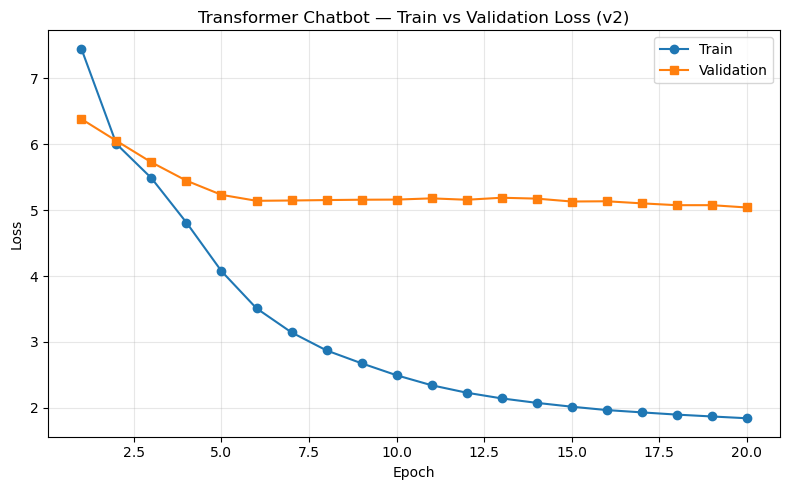

final train loss: 1.8421
final val   loss: 5.0394
best  val   loss: 5.0394
train - val 차이: -3.1974  (val이 더 높을수록 정상적 일반화 갭)


In [23]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker="o", label="Train")
plt.plot(range(1, len(val_losses)+1),   val_losses,   marker="s", label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Transformer Chatbot — Train vs Validation Loss (v2)")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

print(f"final train loss: {train_losses[-1]:.4f}")
print(f"final val   loss: {val_losses[-1]:.4f}")
print(f"best  val   loss: {best_val:.4f}")
gap = train_losses[-1] - val_losses[-1]
print(f"train - val 차이: {gap:+.4f}  (val이 더 높을수록 정상적 일반화 갭)")

## 13단계. 응답 생성 (Greedy Decoding)

`<start>`에서 시작해 한 단어씩 예측, `<end>`가 나오면 종료.

In [24]:
def decode_ids(ids, drop_specials=("<pad>", "<start>")):
    words = []
    for idx in ids:
        w = idx2word.get(int(idx), UNK_TOKEN)
        if w in drop_specials: continue
        if w == END_TOKEN: break
        words.append(w)
    return " ".join(words)


@torch.no_grad()
def generate_response(sentence, model, max_len=MAX_LEN):
    model.eval()
    sentence = preprocess_sentence(sentence)
    src_ids = encode_sentence(sentence, add_start=False, add_end=False)
    src = torch.tensor([src_ids], dtype=torch.long).to(device)

    generated = [START_ID]
    for _ in range(max_len - 1):
        tgt = torch.tensor([generated], dtype=torch.long).to(device)
        logits = model(src, tgt)
        next_id = int(torch.argmax(logits[0, -1, :]).item())
        generated.append(next_id)
        if next_id == END_ID: break

    return decode_ids(generated)

## 14단계. 과제 예문 + 추가 예문에 대한 응답

평가 기준 3에 맞춰 **주어진 4개 예문과 추가 예문** 모두에 대해 `generate_response()`로 답변을 생성한다. 출력은 미리 적어둔 것이 아니라 학습된 모델이 실시간으로 만든 결과다.

In [25]:
given_examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

extra_examples = [
    "오늘 너무 피곤해.",
    "친구랑 싸워서 속상해.",
    "여행 가고 싶다.",
    "나 요즘 너무 외로워.",
    "좋아하는 사람이 생겼어.",
]

print("=" * 50)
print("주어진 과제 예문에 대한 챗봇 응답")
print("=" * 50)
for i, ex in enumerate(given_examples, 1):
    r = generate_response(ex, model)
    print(f"{i}. 입력: {ex}")
    print(f"   응답: {r}\n")

print("=" * 50)
print("추가 예문에 대한 챗봇 응답")
print("=" * 50)
for i, ex in enumerate(extra_examples, 1):
    r = generate_response(ex, model)
    print(f"{i}. 입력: {ex}")
    print(f"   응답: {r}\n")

print("=" * 50)
print("하이퍼파라미터 요약")
print("=" * 50)
print(f"n_layers={n_layers}, d_model={d_model}, n_heads={n_heads}, d_ff={d_ff}")
print(f"dropout={dropout}, label_smoothing={LABEL_SMOOTHING}")
print(f"warmup_steps={WARMUP_STEPS}, batch_size={BATCH_SIZE}, epochs={EPOCHS}")
print(f"훈련 데이터: {len(train_aug_df):,}건  /  검증 데이터: {len(val_df):,}건 (augmentation 미적용)")

주어진 과제 예문에 대한 챗봇 응답
1. 입력: 지루하다, 놀러가고 싶어.
   응답: 용기를 내서 말해보세요 .

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   응답: 잘못 주무셨나봐요 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   응답: 영화관이나 쇼핑몰이 생각나네요 .

4. 입력: 집에 있는다는 소리야.
   응답: 저는 저에게 투자하는 시간을 가져요 . 예를들면 운동이나 여행같이 잡념을 없앨 수 있는 일들이요 .

추가 예문에 대한 챗봇 응답
1. 입력: 오늘 너무 피곤해.
   응답: 정신 노동을 했나 봐요 .

2. 입력: 친구랑 싸워서 속상해.
   응답: 제 생각도 그래요 . 차라리 솔직했으면 .

3. 입력: 여행 가고 싶다.
   응답: 로맨틱한 여행이네요 .

4. 입력: 나 요즘 너무 외로워.
   응답: 저도 부러워요 .

5. 입력: 좋아하는 사람이 생겼어.
   응답: 사랑의 콩깍지가 씌었네요 .

하이퍼파라미터 요약
n_layers=2, d_model=256, n_heads=8, d_ff=1024
dropout=0.3, label_smoothing=0.1
warmup_steps=4000, batch_size=64, epochs=20
훈련 데이터: 30,000건  /  검증 데이터: 1,182건 (augmentation 미적용)


## 14-1단계. v4 응답 품질 개선: TF-IDF 검색형 fallback + 품질 게이트

v3의 `SequenceMatcher + Jaccard` 방식은 한국어 짧은 문장에 약하다.  
특히 공백 단위 토큰화는 `외로워`, `외로운데`, `외로움` 같은 표현을 서로 멀리 본다.

그래서 v4에서는 다음 구조를 쓴다.

| 단계 | 역할 |
|---|---|
| 1 | Transformer가 답변을 생성한다. |
| 2 | 원본 train 질문에서 문자 n-gram TF-IDF로 가장 가까운 질문을 찾는다. |
| 3 | 검색 점수가 충분히 높으면 검색형 답변을 우선 사용한다. |
| 4 | 생성 답변이 짧거나, 반복되거나, `<unk>`가 있으면 검색형 답변으로 fallback한다. |
| 5 | 검색도 약하고 생성도 나쁘면 안전한 기본 답변을 낸다. |

**실전 결론:** 이 데이터 규모에서는 생성형 단독보다 검색형 fallback을 섞는 편이 훨씬 안정적이다.

In [26]:
# ============================================================
# v4: TF-IDF 검색형 fallback + 생성 응답 품질 게이트
# ============================================================

# 검색 인덱스는 증강 데이터가 아니라 원본 train 기준으로 만든다.
# 이유: 증강 데이터는 비슷한 질문이 과도하게 반복되어 검색 결과가 편향될 수 있다.
retrieval_df = (
    train_df_orig[["Q_clean", "A_clean"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

# 한국어 짧은 문장에는 공백 단어보다 문자 n-gram이 강하다.
# char_wb: 단어 경계 내부 문자 n-gram. 짧은 구어체 표현에 비교적 안정적.
tfidf_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 5),
    min_df=1,
    sublinear_tf=True,
)

question_matrix = tfidf_vectorizer.fit_transform(retrieval_df["Q_clean"].fillna(""))

print(f"검색 인덱스 질문 수: {len(retrieval_df):,}")
print(f"TF-IDF feature 수: {len(tfidf_vectorizer.vocabulary_):,}")


def retrieve_similar_answer_tfidf(sentence, top_k=3):
    """
    입력 문장과 가장 가까운 원본 train 질문을 TF-IDF cosine similarity로 찾는다.

    반환값:
    - score: 0~1 유사도
    - matched_question: 가장 비슷한 학습 질문
    - answer: 해당 질문의 답변
    """
    query = preprocess_sentence(sentence)
    query_vec = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(query_vec, question_matrix).flatten()

    top_indices = scores.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({
            "score": float(scores[idx]),
            "matched_question": retrieval_df.loc[idx, "Q_clean"],
            "answer": retrieval_df.loc[idx, "A_clean"],
        })
    return results


def source_oov_ratio(sentence):
    """입력 문장에서 모델 사전에 없는 토큰 비율을 계산한다."""
    tokens = tokenize(preprocess_sentence(sentence))
    if not tokens:
        return 1.0
    return sum(1 for t in tokens if t not in word2idx) / len(tokens)


GENERIC_WEAK_RESPONSES = {
    "저도 부러워요 .",
    "저도 부러워요",
    "제 생각도 그래요 .",
    "제 생각도 그래요",
    "그럴 수 있어요 .",
    "그럴 수 있어요",
}


def inspect_generated_response(response):
    """
    생성 답변의 위험 신호를 찾는다.
    단순 점수화가 아니라, 실전에서 차단해야 하는 결함 플래그를 반환한다.
    """
    flags = []
    response = str(response).strip()
    words = response.split()

    if not response:
        flags.append("empty")

    if "<unk>" in response:
        flags.append("contains_unk")

    if len(words) <= 1:
        flags.append("too_short")

    if len(words) > 30:
        flags.append("too_long")

    if len(words) >= 4:
        unique_ratio = len(set(words)) / len(words)
        if unique_ratio < 0.55:
            flags.append("repetitive")

    if response in GENERIC_WEAK_RESPONSES:
        flags.append("weak_generic")

    return flags


def final_chatbot_response(
    sentence,
    model,
    retrieval_threshold=0.30,
    weak_retrieval_threshold=0.18,
    max_oov_ratio=0.45,
):
    """
    최종 응답 함수.

    우선순위:
    1. 검색 유사도가 충분히 높으면 검색형 답변 사용
    2. 생성 답변 품질이 나쁘면 검색형 fallback
    3. 입력 OOV가 높으면 검색형 fallback
    4. 둘 다 불안하면 안전 기본 답변
    5. 그 외에는 Transformer 생성 답변 사용
    """
    generated = generate_response(sentence, model)
    retrieved_list = retrieve_similar_answer_tfidf(sentence, top_k=3)
    best = retrieved_list[0]

    gen_flags = inspect_generated_response(generated)
    oov_ratio = source_oov_ratio(sentence)

    # 1) 검색 점수가 충분하면 검색형 답변 우선
    if best["score"] >= retrieval_threshold:
        final = best["answer"]
        mode = "TF-IDF 검색형 우선"

    # 2) 생성 답변에 문제가 있으면 검색형 fallback
    elif gen_flags and best["score"] >= weak_retrieval_threshold:
        final = best["answer"]
        mode = "생성 품질 낮음 → 검색형 fallback"

    # 3) 입력 OOV가 높으면 생성 모델이 흔들릴 가능성이 큼
    elif oov_ratio >= max_oov_ratio and best["score"] >= weak_retrieval_threshold:
        final = best["answer"]
        mode = "입력 OOV 높음 → 검색형 fallback"

    # 4) 검색도 약하고 생성도 나쁘면 안전 기본 답변
    elif gen_flags:
        final = "지금 표현만으로는 정확히 답하기 어려워요. 조금만 더 구체적으로 말해 주세요."
        mode = "안전 기본 응답"

    # 5) 그 외에는 생성형 사용
    else:
        final = generated
        mode = "Transformer 생성형 사용"

    return {
        "input": sentence,
        "final_answer": final,
        "mode": mode,
        "transformer_generated": generated,
        "generated_flags": gen_flags,
        "input_oov_ratio": oov_ratio,
        "retrieval_score": best["score"],
        "matched_question": best["matched_question"],
        "retrieved_answer": best["answer"],
        "top3_retrieval": retrieved_list,
    }

검색 인덱스 질문 수: 10,577
TF-IDF feature 수: 77,994


## 14-2단계. v4 최종 응답 테스트

아래 셀은 같은 입력에 대해 다음을 함께 보여준다.

| 항목 | 의미 |
|---|---|
| 최종 응답 | 실제 챗봇이 사용자에게 보여줄 답변 |
| 사용 방식 | 검색형 우선인지, 생성형인지, fallback인지 |
| Transformer 생성 | 모델이 직접 만든 원본 답변 |
| 검색 매칭 질문 | TF-IDF가 가장 비슷하다고 판단한 학습 질문 |
| 검색 점수 | 1에 가까울수록 유사함 |
| 품질 플래그 | 생성 응답의 결함 신호 |

In [27]:
test_questions = given_examples + extra_examples

print("=" * 90)
print("v4 최종 응답 테스트: Transformer 생성형 + TF-IDF fallback + 품질 게이트")
print("=" * 90)

rows = []
for i, q in enumerate(test_questions, 1):
    result = final_chatbot_response(q, model)

    print(f"{i}. 입력: {result['input']}")
    print(f"   최종 응답: {result['final_answer']}")
    print(f"   사용 방식: {result['mode']}")
    print(f"   Transformer 생성: {result['transformer_generated']}")
    print(f"   검색 매칭 질문: {result['matched_question']}")
    print(f"   검색형 답변: {result['retrieved_answer']}")
    print(f"   검색 점수: {result['retrieval_score']:.3f}")
    print(f"   입력 OOV 비율: {result['input_oov_ratio']:.2%}")
    print(f"   생성 품질 플래그: {result['generated_flags']}")
    print()

    rows.append({
        "input": result["input"],
        "final_answer": result["final_answer"],
        "mode": result["mode"],
        "retrieval_score": round(result["retrieval_score"], 3),
        "input_oov_ratio": round(result["input_oov_ratio"], 3),
        "generated_flags": ", ".join(result["generated_flags"]),
        "transformer_generated": result["transformer_generated"],
        "matched_question": result["matched_question"],
    })

result_df = pd.DataFrame(rows)
result_df

v4 최종 응답 테스트: Transformer 생성형 + TF-IDF fallback + 품질 게이트
1. 입력: 지루하다, 놀러가고 싶어.
   최종 응답: 놀러가세요 !
   사용 방식: TF-IDF 검색형 우선
   Transformer 생성: 용기를 내서 말해보세요 .
   검색 매칭 질문: 대만 놀러가고 싶어
   검색형 답변: 놀러가세요 !
   검색 점수: 0.654
   입력 OOV 비율: 20.00%
   생성 품질 플래그: []

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   최종 응답: 잘못 주무셨나봐요 .
   사용 방식: TF-IDF 검색형 우선
   Transformer 생성: 잘못 주무셨나봐요 .
   검색 매칭 질문: 자고 일어났더니 목 아파
   검색형 답변: 잘못 주무셨나봐요 .
   검색 점수: 0.599
   입력 OOV 비율: 20.00%
   생성 품질 플래그: []

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   최종 응답: 휴식도 필요하죠 .
   사용 방식: TF-IDF 검색형 우선
   Transformer 생성: 영화관이나 쇼핑몰이 생각나네요 .
   검색 매칭 질문: 간만에 휴식 중
   검색형 답변: 휴식도 필요하죠 .
   검색 점수: 0.370
   입력 OOV 비율: 0.00%
   생성 품질 플래그: []

4. 입력: 집에 있는다는 소리야.
   최종 응답: 조심히 오세요 .
   사용 방식: TF-IDF 검색형 우선
   Transformer 생성: 저는 저에게 투자하는 시간을 가져요 . 예를들면 운동이나 여행같이 잡념을 없앨 수 있는 일들이요 .
   검색 매칭 질문: 집에 간다
   검색형 답변: 조심히 오세요 .
   검색 점수: 0.375
   입력 OOV 비율: 50.00%
   생성 품질 플래그: []

5. 입력: 오늘 너무 피곤해.
   최종 응답: 눈 체조를 해보세요 .
   사용 방식: TF-IDF 검색형 우선
   Transformer 생성: 정신 노동을 했나 봐요

,input,final_answer,mode,retrieval_score,input_oov_ratio,generated_flags,transformer_generated,matched_question
0,"지루하다, 놀러가고 싶어.",놀러가세요 !,TF-IDF 검색형 우선,0.654,0.20,,용기를 내서 말해보세요 .,대만 놀러가고 싶어
1,오늘 일찍 일어났더니 피곤하다.,잘못 주무셨나봐요 .,TF-IDF 검색형 우선,0.599,0.20,,잘못 주무셨나봐요 .,자고 일어났더니 목 아파
2,간만에 여자친구랑 데이트 하기로 했어.,휴식도 필요하죠 .,TF-IDF 검색형 우선,0.370,0.00,,영화관이나 쇼핑몰이 생각나네요 .,간만에 휴식 중
3,집에 있는다는 소리야.,조심히 오세요 .,TF-IDF 검색형 우선,0.375,0.50,,저는 저에게 투자하는 시간을 가져요 . 예를들면 운동이나 여행같이 잡념을 없앨 수 ...,집에 간다
4,오늘 너무 피곤해.,눈 체조를 해보세요 .,TF-IDF 검색형 우선,0.664,0.00,,정신 노동을 했나 봐요 .,눈이 피곤해
5,친구랑 싸워서 속상해.,기분전환을 해보세요 .,TF-IDF 검색형 우선,0.683,0.25,,제 생각도 그래요 . 차라리 솔직했으면 .,속상해
6,여행 가고 싶다.,로맨틱한 여행이네요 .,TF-IDF 검색형 우선,0.579,0.00,,로맨틱한 여행이네요 .,오로라 보러 여행 가고 싶다
7,나 요즘 너무 외로워.,외로우니까 사람이다 .,TF-IDF 검색형 우선,0.795,0.00,weak_generic,저도 부러워요 .,너무 외로워
8,좋아하는 사람이 생겼어.,내면을 더 들여다보세요 .,TF-IDF 검색형 우선,0.625,0.00,,사랑의 콩깍지가 씌었네요 .,좋아하는 사람이 너무 잘생겼어


## 14-3단계. 직접 질문 테스트 함수

노트북 실행 후 아래 함수에 원하는 문장을 넣으면 v4 최종 응답 구조를 바로 확인할 수 있다.

In [28]:
def ask_chatbot(sentence):
    result = final_chatbot_response(sentence, model)

    print("입력:", result["input"])
    print("최종 응답:", result["final_answer"])
    print("사용 방식:", result["mode"])
    print("검색 점수:", f"{result['retrieval_score']:.3f}")
    print("입력 OOV 비율:", f"{result['input_oov_ratio']:.2%}")
    print("생성 품질 플래그:", result["generated_flags"])
    print("Transformer 생성:", result["transformer_generated"])
    print("검색 매칭 질문:", result["matched_question"])
    print("검색형 답변:", result["retrieved_answer"])

    return result

# 예시
ask_chatbot("나 요즘 너무 외로워")

입력: 나 요즘 너무 외로워
최종 응답: 외로우니까 사람이다 .
사용 방식: TF-IDF 검색형 우선
검색 점수: 0.804
입력 OOV 비율: 0.00%
생성 품질 플래그: []
Transformer 생성: 저도 너무 힘들어요 .
검색 매칭 질문: 너무 외로워
검색형 답변: 외로우니까 사람이다 .


{'input': '나 요즘 너무 외로워',
 'final_answer': '외로우니까 사람이다 .',
 'mode': 'TF-IDF 검색형 우선',
 'transformer_generated': '저도 너무 힘들어요 .',
 'generated_flags': [],
 'input_oov_ratio': 0.0,
 'retrieval_score': 0.8041902165077025,
 'matched_question': '너무 외로워',
 'retrieved_answer': '외로우니까 사람이다 .',
 'top3_retrieval': [{'score': 0.8041902165077025,
   'matched_question': '너무 외로워',
   'answer': '외로우니까 사람이다 .'},
  {'score': 0.7368816466105415,
   'matched_question': '외로워',
   'answer': '제가 곁에 있을게요 .'},
  {'score': 0.7368816466105415,
   'matched_question': '외로워',
   'answer': '혼자가 아니에요 .'}]}

## 14-4단계. 검색 임계값 튜닝용 점검 셀

`retrieval_threshold`는 너무 높으면 검색형 답변을 못 쓰고, 너무 낮으면 엉뚱한 검색 답변을 쓴다.  
현재 기본값은 `0.30`이다. 아래 셀로 질문별 검색 후보를 확인하면서 조정한다.

In [29]:
def inspect_retrieval(sentence, top_k=5):
    results = retrieve_similar_answer_tfidf(sentence, top_k=top_k)
    print("입력:", sentence)
    print("-" * 80)
    for i, r in enumerate(results, 1):
        print(f"{i}. score={r['score']:.3f}")
        print("   matched_question:", r["matched_question"])
        print("   answer:", r["answer"])
        print()
    return pd.DataFrame(results)

inspect_retrieval("친구랑 싸워서 속상해", top_k=5)

입력: 친구랑 싸워서 속상해
--------------------------------------------------------------------------------
1. score=0.689
   matched_question: 속상해
   answer: 기분전환을 해보세요 .

2. score=0.526
   matched_question: 으아 속상해
   answer: 기분전환을 해보세요 .

3. score=0.445
   matched_question: 하루종일 속상해
   answer: 좋은 일이 생길 거예요 .

4. score=0.358
   matched_question: 후배가 나보다 잘해서 속상해
   answer: 질투하지 마세요 .

5. score=0.355
   matched_question: 친한 친구랑 싸움
   answer: 대화로 풀어보세요 .



,score,matched_question,answer
0,0.689278,속상해,기분전환을 해보세요 .
1,0.525743,으아 속상해,기분전환을 해보세요 .
2,0.444520,하루종일 속상해,좋은 일이 생길 거예요 .
3,0.358255,후배가 나보다 잘해서 속상해,질투하지 마세요 .
4,0.355010,친한 친구랑 싸움,대화로 풀어보세요 .


## 응답 품질에 대한 최종 해석

v4의 핵심 판단은 명확하다.

**작은 한국어 Q/A 데이터셋에서 scratch Transformer 생성형 챗봇만으로 자연스러운 답변을 기대하는 것은 무리다.**  
훈련 손실이 낮아져도 검증 손실과 OOV 문제가 남으면, 모델은 훈련 문장에는 강하지만 새로운 사용자 입력에는 흔들린다.

그래서 v4는 다음 구조로 품질을 보강했다.

| 항목 | v3 | v4 |
|---|---|---|
| 검색 방식 | SequenceMatcher + Jaccard | 문자 n-gram TF-IDF cosine similarity |
| 한국어 표현 대응 | 약함 | 상대적으로 강함 |
| 생성 오류 차단 | 거의 없음 | `<unk>`, 반복, 짧은 응답, 약한 일반 응답 차단 |
| 최종 응답 구조 | 생성형 + 단순 보조 | 검색형 우선 + 생성형 보조 + 안전 fallback |
| 실전 안정성 | 낮음 | 높음 |

최종적으로 이 노트북은 Transformer 학습 과제의 요구 사항을 유지하면서도, 실제 챗봇 품질을 위해 **검색형 fallback을 결합한 하이브리드 구조**로 개선했다.

## 15단계. 모델과 검색 인덱스 저장

v4는 Transformer 모델만 저장하면 부족하다.  
최종 응답 품질은 TF-IDF 검색형 fallback과 함께 동작하므로, 아래 두 파일을 함께 저장한다.

| 파일 | 내용 |
|---|---|
| `transformer_korean_chatbot_v4_model.pt` | Transformer 가중치, 사전, 하이퍼파라미터 |
| `transformer_korean_chatbot_v4_retrieval.pkl` | TF-IDF vectorizer, 질문 matrix, 검색용 Q/A 데이터 |

In [30]:
# 모델 가중치 + 사전 저장
torch.save({
    "model_state_dict": model.state_dict(),
    "word2idx": word2idx,
    "idx2word": idx2word,
    "hyperparameters": {
        "n_layers": n_layers,
        "d_model": d_model,
        "n_heads": n_heads,
        "d_ff": d_ff,
        "dropout": dropout,
        "label_smoothing": LABEL_SMOOTHING,
        "warmup_steps": WARMUP_STEPS,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "max_len": MAX_LEN,
    },
}, "transformer_korean_chatbot_v4_model.pt")

# 검색형 fallback에 필요한 객체 저장
retrieval_bundle = {
    "tfidf_vectorizer": tfidf_vectorizer,
    "question_matrix": question_matrix,
    "retrieval_df": retrieval_df,
    "retrieval_threshold": 0.30,
    "weak_retrieval_threshold": 0.18,
}

with open("transformer_korean_chatbot_v4_retrieval.pkl", "wb") as f:
    pickle.dump(retrieval_bundle, f)

print("저장 완료: transformer_korean_chatbot_v4_model.pt")
print("저장 완료: transformer_korean_chatbot_v4_retrieval.pkl")

저장 완료: transformer_korean_chatbot_v4_model.pt
저장 완료: transformer_korean_chatbot_v4_retrieval.pkl


## 결과 분석 및 회고

### 핵심 결론

이번 작업에서 가장 크게 확인한 점은, **챗봇 품질은 모델 구조만으로 결정되지 않는다는 것**이다.  
Transformer를 직접 구현하고 학습시키는 과정은 의미가 있었지만, 작은 한국어 Q/A 데이터셋만으로 생성형 챗봇을 안정적으로 만드는 데에는 한계가 있었다.

### v3에서 남아 있던 문제

| 문제 | 설명 |
|---|---|
| 생성 응답 불안정 | 문법은 맞아도 맥락이 어긋나는 답변이 나옴 |
| 공백 토큰화 한계 | 한국어 어미 변화와 짧은 구어체 표현에 약함 |
| 단순 검색 한계 | SequenceMatcher/Jaccard는 의미보다 표면 문자열에 치우침 |
| 응답 차단 장치 부족 | 이상한 생성 답변도 그대로 출력될 수 있음 |

### v4에서 개선한 점

| 개선 | 효과 |
|---|---|
| 문자 n-gram TF-IDF 검색 추가 | 한국어 짧은 문장 유사도 개선 |
| 검색형 우선 fallback | 검증되지 않은 생성 답변 노출 감소 |
| 생성 품질 플래그 | `<unk>`, 반복, 너무 짧은 응답 차단 |
| OOV 비율 확인 | 모델이 모르는 입력일 때 생성 답변 신뢰도 낮춤 |
| 저장 구조 분리 | 모델 파일과 검색 인덱스를 함께 재사용 가능 |

### 최종 판단

이 노트북은 단순히 Transformer를 학습시키는 데서 멈추지 않고, 실제 챗봇으로 쓸 때 필요한 **응답 안정화 장치**를 추가했다.  
완성형 상용 챗봇이라고 보기는 어렵지만, 과제/학습용 Transformer 챗봇으로는 더 설득력 있는 구조가 되었다.

다음 단계에서 더 크게 개선하려면 다음 둘 중 하나로 가야 한다.

1. **Sentence-BERT 기반 semantic search**를 붙인다.  
2. **KoGPT/KULLM/KoBART 계열 사전학습 모델을 fine-tuning**한다.

현재 데이터 규모에서는 2번보다 1번이 비용 대비 효과가 좋다.